# Notebook 04 — Cell Ranger count-output QC

**Project:** snRNA-seq transgene detection in *Arabidopsis* (Col-0)

**Purpose:** QC a `cellranger count` output — mapping/multi-mapping stats, cell-calling
(UMI per barcode, cells vs background), the barcode-rank separation, a `--force-cells`
comparison, and reference/transgene validation.

Set `SAMPLE_OUTS` below to any sample's `outs/` folder to reuse this notebook
(Col-0, pFACT-MYB41, pHORST-MYB41). Background on the algorithm: `notes/04_cellranger_cell_calling.md`.


## Step 0 — Setup

In [3]:
import os, gzip, csv
import numpy as np, pandas as pd, scipy.io
import matplotlib.pyplot as plt

SAMPLE_OUTS = "/data1/bfernando/DE_project/Col-0_v4/outs"  
SAMPLE = os.path.basename(os.path.dirname(SAMPLE_OUTS))
print("sample outs:", SAMPLE_OUTS)

def load_mtx(mtx_dir):
    """Return (matrix genes x barcodes, features_df) from a 10x matrix folder."""
    with gzip.open(f"{mtx_dir}/matrix.mtx.gz") as fh:
        M = scipy.io.mmread(fh).tocsc()
    feats = pd.read_csv(f"{mtx_dir}/features.tsv.gz", sep="\t", header=None,
                        names=["gene_id","gene_name","type"])
    return M, feats


sample outs: /data1/bfernando/DE_project/Col-0_v4/outs


## Step 1 — Mapping & multi-mapping stats

From `metrics_summary.csv`. Cell Ranger reports "% mapped to genome" (any, incl.
multi-mappers) and "% mapped confidently" (unique). **Multi-mapping is derived** as the
difference between the two.


In [5]:
m = dict(zip(*list(csv.reader(open(f"{SAMPLE_OUTS}/metrics_summary.csv")))))
def num(s): return float(s.replace(",","").replace("%",""))

total   = num(m["Number of Reads"])
mapped  = num(m["Reads Mapped to Genome"])
unique  = num(m["Reads Mapped Confidently to Genome"])
multi   = mapped - unique

print(f"Total reads                 : {total:,.0f}")
print(f"Mapped to genome (any)      : {mapped:5.1f}%   ({total*mapped/100:,.0f})  -> index works")
print(f"Mapped confidently (unique) : {unique:5.1f}%   ({total*unique/100:,.0f})")
print(f"--> MULTI-MAPPING (derived) : {multi:5.1f}%   ({total*multi/100:,.0f})  = 98% - unique")
print("\nWhere the CONFIDENT reads land:")
for k in ["Reads Mapped Confidently to Transcriptome","Reads Mapped Confidently to Exonic Regions",
          "Reads Mapped Confidently to Intronic Regions","Reads Mapped Confidently to Intergenic Regions",
          "Reads Mapped Antisense to Gene"]:
    print(f"   {k:48}: {m[k]}")
print("\nCell metrics:")
for k in ["Estimated Number of Cells","Fraction Reads in Cells","Mean Reads per Cell",
          "Median Genes per Cell","Median UMI Counts per Cell","Total Genes Detected"]:
    print(f"   {k:32}: {m[k]}")


Total reads                 : 458,636,011
Mapped to genome (any)      :  98.0%   (449,463,291)  -> index works
Mapped confidently (unique) :  31.8%   (145,846,251)
--> MULTI-MAPPING (derived) :  66.2%   (303,617,039)  = 98% - unique

Where the CONFIDENT reads land:
   Reads Mapped Confidently to Transcriptome       : 16.2%
   Reads Mapped Confidently to Exonic Regions      : 17.4%
   Reads Mapped Confidently to Intronic Regions    : 0.2%
   Reads Mapped Confidently to Intergenic Regions  : 14.2%
   Reads Mapped Antisense to Gene                  : 1.4%

Cell metrics:
   Estimated Number of Cells       : 864
   Fraction Reads in Cells         : 23.0%
   Mean Reads per Cell             : 530,829
   Median Genes per Cell           : 998
   Median UMI Counts per Cell      : 1,380
   Total Genes Detected            : 20,547


## Step 2 — Cell-calling QC (UMI per barcode: cells vs background)

Compares the called cells (filtered matrix) against all barcodes (raw matrix). The key
check is **separation**: is there a gap between the lowest-UMI cell and the highest-UMI
background barcode? (No gap = no clean knee = ambient-dominated.)


In [3]:
cellM, feats = load_mtx(f"{SAMPLE_OUTS}/filtered_feature_bc_matrix")
rawM,  _     = load_mtx(f"{SAMPLE_OUTS}/raw_feature_bc_matrix")
cell_bcs = np.array([l.strip() for l in gzip.open(f"{SAMPLE_OUTS}/filtered_feature_bc_matrix/barcodes.tsv.gz","rt")])
raw_bcs  = np.array([l.strip() for l in gzip.open(f"{SAMPLE_OUTS}/raw_feature_bc_matrix/barcodes.tsv.gz","rt")])

cell_umi = np.asarray(cellM.sum(axis=0)).ravel()
raw_umi  = np.asarray(rawM.sum(axis=0)).ravel()

print("=== CALLED CELLS ===")
print(f"  cells: {len(cell_bcs):,}   UMI/cell  min={cell_umi.min():.0f} max={cell_umi.max():.0f} "
      f"mean={cell_umi.mean():.0f} median={np.median(cell_umi):.0f}")
nz = raw_umi>0
print("=== ALL BARCODES (raw) ===")
print(f"  barcodes>=1 UMI: {nz.sum():,}   median={np.median(raw_umi[nz]):.0f}")

is_cell = np.isin(raw_bcs, cell_bcs)
bg_umi  = raw_umi[~is_cell & (raw_umi>0)]
print("=== SEPARATION (cliff check) ===")
print(f"  lowest UMI among CELLS       : {cell_umi.min():.0f}")
print(f"  highest UMI among BACKGROUND : {bg_umi.max():.0f}")
print(f"  -> {'OVERLAP (no clean cliff)' if bg_umi.max()>=cell_umi.min() else 'clean separation'}")


=== CALLED CELLS ===
  cells: 864   UMI/cell  min=502 max=62119 mean=3238 median=1380
=== ALL BARCODES (raw) ===
  barcodes>=1 UMI: 434,353   median=1
=== SEPARATION (cliff check) ===
  lowest UMI among CELLS       : 502
  highest UMI among BACKGROUND : 5153
  -> OVERLAP (no clean cliff)


## Step 3 — Barcode-rank plot (cells vs background)

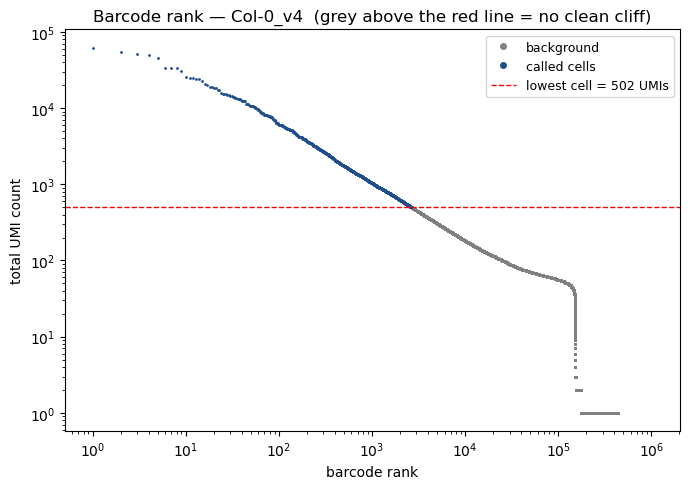

In [4]:
order = np.argsort(raw_umi)[::-1]
ranks = np.arange(1, len(order)+1)
r_umi, r_cell = raw_umi[order], is_cell[order]
fig, ax = plt.subplots(figsize=(7,5))
ax.loglog(ranks[~r_cell], r_umi[~r_cell], ".", ms=2, color="grey",    label="background")
ax.loglog(ranks[r_cell],  r_umi[r_cell],  ".", ms=2, color="#1f4e8c", label="called cells")
ax.axhline(cell_umi.min(), color="red", ls="--", lw=1, label=f"lowest cell = {cell_umi.min():.0f} UMIs")
ax.set_xlabel("barcode rank"); ax.set_ylabel("total UMI count")
ax.set_title(f"Barcode rank — {SAMPLE}  (grey above the red line = no clean cliff)")
ax.legend(markerscale=4, fontsize=9); plt.tight_layout(); plt.show()


## Step 4 — `--force-cells` comparison (quality vs quantity)

`--force-cells N` just takes the top N barcodes by UMI. This compares the default
(EmptyDrops) cell set against forcing 2,000 and 3,000 — showing that more cells means
lower per-cell quality and little gain in total genes detected.


In [5]:
def summarize(M, feats, label):
    umi=np.asarray(M.sum(axis=0)).ravel(); genes=np.asarray((M>0).sum(axis=0)).ravel()
    org=feats.gene_id.str.startswith(("ATMG","ATCG")).values
    of=np.divide(np.asarray(M[org].sum(axis=0)).ravel(),umi,out=np.zeros(len(umi)),where=umi>0)
    return dict(run=label, cells=M.shape[1], med_UMI=int(np.median(umi)),
                med_genes=int(np.median(genes)), med_pct_organellar=round(100*np.median(of),1),
                total_genes=int((np.asarray(M.sum(axis=1)).ravel()>0).sum()))

rows=[summarize(cellM, feats, "default (EmptyDrops)")]
for N in [2000, 3000]:
    rows.append(summarize(rawM[:, order[:N]], feats, f"force-cells {N}"))
pd.DataFrame(rows)[["run","cells","med_UMI","med_genes","med_pct_organellar","total_genes"]]


,run,cells,med_UMI,med_genes,med_pct_organellar,total_genes
0,default (EmptyDrops),864,1379,997,3.8,20547
1,force-cells 2000,2000,1034,783,5.3,20939
2,force-cells 3000,3000,772,611,5.3,21095


## Step 5 — Reference / transgene validation

Confirms the reference is functional and specific: sensible top genes, native MYB41
(`AT4G28110`) detected, and the transgene (`AT4G28110.Fusion`). In the **WT control**
the fusion should be **0**; in **pFACT/pHORST** it should be **> 0** (the transgene signal).


In [6]:
gene_umi = np.asarray(cellM.sum(axis=1)).ravel()
feats = feats.assign(total_umi=gene_umi)
print(f"total genes detected: {(gene_umi>0).sum():,}\n")
print("TOP 10 expressed genes (should be sensible Arabidopsis genes):")
print(feats.sort_values("total_umi",ascending=False).head(10)[["gene_id","gene_name","total_umi"]].to_string(index=False))
print("\nMYB41 native vs transgene:")
print(feats[feats.gene_id.str.contains("AT4G28110")][["gene_id","gene_name","total_umi"]].to_string(index=False))
fus = feats[feats.gene_id=="AT4G28110.Fusion"]["total_umi"].sum()
print(f"\n>>> transgene (AT4G28110.Fusion) total UMIs in {SAMPLE}: {int(fus)}")
print("    (expect 0 in WT Col-0; >0 in pFACT / pHORST)")


total genes detected: 20,547

TOP 10 expressed genes (should be sensible Arabidopsis genes):
                gene_id               gene_name  total_umi
ATMG00090.Araport11.447                    RPS3      22696
AT5G60390.Araport11.447 AT5G60390.Araport11.447      14857
ATMG00580.Araport11.447                    NAD4      11806
AT2G21660.Araport11.447                    GRP7      10658
AT5G02500.Araport11.447                 HSC70-1       7067
AT1G07590.Araport11.447 AT1G07590.Araport11.447       6893
AT3G09260.Araport11.447                   PYK10       6837
AT3G16640.Araport11.447                    TCTP       6705
AT4G13940.Araport11.447                    HOG1       6505
AT4G39200.Araport11.447 AT4G39200.Araport11.447       6103

MYB41 native vs transgene:
                gene_id        gene_name  total_umi
AT4G28110.Araport11.447            MYB41          2
       AT4G28110.Fusion AT4G28110.Fusion          0

>>> transgene (AT4G28110.Fusion) total UMIs in Col-0_v4: 0
    (expect 0 

## Summary

- **Mapping:** 98% of reads map to the genome (index works), but only ~32% uniquely —
  ~66% multi-mapping (TSO artifacts + repeats).
- **Cell-calling:** cells and background **overlap** (no clean knee) → high ambient /
  low intact-nuclei recovery.
- **force-cells:** raises the cell count but lowers per-cell quality with little gain in
  total genes → the library, not the pipeline, is the limiter.
- **Reference validated:** sensible top genes; native + fusion MYB41 present; fusion = 0
  in the WT control (correct negative control).
